# Boletín 8: Aprendizaje Supervisado (UD4)
## Capítulos 4.1 – 4.4: Regresión, Árboles, Clasificación y Ensembles

**Objetivo:** Consolidar los conceptos fundamentales del aprendizaje supervisado trabajados en los cuatro capítulos de la unidad.

**Instrucciones:**
- 10 ejercicios ordenados por capítulo y dificultad creciente
- 🟢 Básico | 🟡 Intermedio | 🔴 Avanzado
- Completa el código donde aparece `# Tu código aquí`
- Responde las preguntas teóricas mediante comentarios `#` o cadenas de texto

**Nombres:**   Ivana Sánchez Pérez

---

In [7]:
# colores
rojo = '\033[91m'
verde = '\033[92m'
azul = '\033[94m'
magenta = '\033[95m'
amarillo = '\033[93m'
rosa = '\033[38;5;200m'
turquesa = '\033[38;5;44m'
azul_marino = '\33[38;5;67m'
lima = '\33[38;5;46m'
reset = '\033[0m'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
from sklearn.datasets import load_diabetes, make_classification, make_regression

plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


## 🟢 Ejercicio 1 (Cap. 4.1): Regresión Lineal Simple

Tienes datos de **superficie (m²) y precio de venta (€)** de pisos en una ciudad:

```python
superficie = [40, 55, 65, 75, 80, 90, 100, 110, 120, 140]
precio_miles = [85, 105, 120, 138, 145, 162, 178, 193, 210, 240]
```

**Tareas:**
1. Entrena un modelo de regresión lineal simple
2. Muestra la ecuación obtenida: `precio = a · superficie + b`  
3. Interpreta el coeficiente `a`: ¿cuántos euros más vale un piso por cada m² adicional?
4. Predice el precio de un piso de 95 m²
5. Calcula el R² y comenta el resultado: ¿qué porcentaje de la variación explica el modelo?
6. Visualiza los datos y la recta de regresión en una gráfica


Ecuación: Precio = 1.58 * superficie + 19.50
Por cada m2 adicional, el precio sube 1578.27€
Predicción para 95 m²: 169.44 miles de euros
Coeficiente de determinación R²: 0.9993

El modelo explica el 99.93% de la variación del precio según la superficie.
Al ser muy cercano a 1, indica un ajuste excelente.



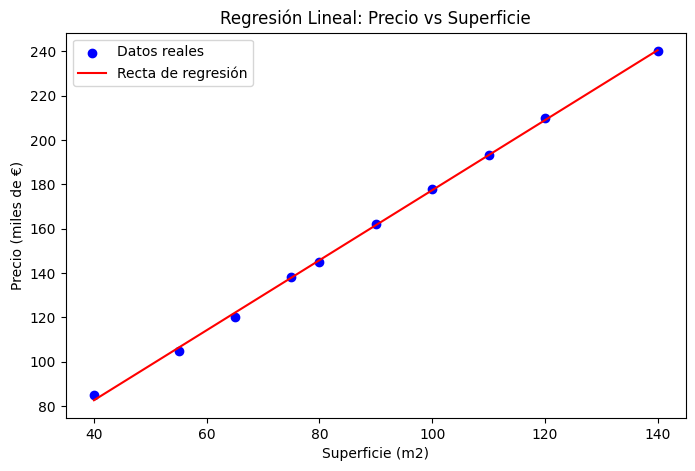

In [8]:
superficie = np.array([40, 55, 65, 75, 80, 90, 100, 110, 120, 140]).reshape(-1, 1)
precio_miles = np.array([85, 105, 120, 138, 145, 162, 178, 193, 210, 240])

# 1. Entrenar modelo de regresión lineal simple
modelo = LinearRegression()
modelo.fit(superficie, precio_miles)

# 2. Mostrar ecuación: precio = a * superficie + b
a = modelo.coef_[0]
b = modelo.intercept_
print(f"{magenta}\nEcuación: {reset}{amarillo}Precio = {a:.2f} * superficie + {b:.2f}{reset}")

# 3. Interpretar coeficiente (comentario)
precio_por_metro = a * 1000
print(f"{magenta}Por cada m2 adicional, el precio sube {precio_por_metro:.2f}€{reset}")

# 4. Predecir precio para 95 m²
prediccion_95 = modelo.predict([[95]])
print(f"{magenta}Predicción para 95 m²:{reset}{amarillo} {prediccion_95[0]:.2f} miles de euros{reset}")

# 5. Calcular R² y comentar
r2 = modelo.score(superficie, precio_miles)
print(f"{magenta}Coeficiente de determinación R²:{reset}{amarillo} {r2:.4f}{reset}")
print(f"{amarillo}\nEl modelo explica el {r2*100:.2f}% de la variación del precio según la superficie.")
print(f"Al ser muy cercano a 1, indica un ajuste excelente.{reset}\n")

# 6. Visualizar datos y recta
plt.scatter(superficie, precio_miles, color='blue', label='Datos reales')
plt.plot(superficie, modelo.predict(superficie), color='red', label='Recta de regresión')
plt.title('Regresión Lineal: Precio vs Superficie')
plt.xlabel('Superficie (m2)')
plt.ylabel('Precio (miles de €)')
plt.legend()
plt.show()


## 🟢 Ejercicio 2 (Cap. 4.1): Métricas de Evaluación en Regresión

Un modelo predice el **consumo eléctrico mensual (kWh)** de viviendas. Se obtienen los siguientes resultados:

```python
y_real = [320, 450, 290, 510, 380, 420, 340, 480]
y_pred = [305, 470, 280, 495, 400, 410, 360, 460]
```

**Tareas:**
1. Calcula manualmente (con operaciones de NumPy, sin sklearn) el **MAE**, **MSE** y **RMSE**
2. Calcula el **R²** usando `r2_score` de sklearn y también de forma manual con la fórmula:  
   $R^2 = 1 - \dfrac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$
3. Verifica los resultados de MAE y MSE con las funciones de sklearn
4. ¿En qué unidades está el RMSE? ¿Por qué es más interpretable que el MSE?
5. El R² obtenido, ¿indica un buen ajuste? Justifica tu respuesta

In [6]:
y_real = np.array([320, 450, 290, 510, 380, 420, 340, 480])
y_pred = np.array([305, 470, 280, 495, 400, 410, 360, 460])

# 1. MAE manual (sin sklearn)
errores = y_real - y_pred
mae_manual = np.mean(np.abs(errores))
mse_manual = np.mean(errores**2)
rmse_manual = np.sqrt(mse_manual)

print(f"{magenta}MAE:{reset}{amarillo} {mae_manual:.2f}{reset}")

# 1. MSE manual
print(f"{magenta}MSE:{reset}{amarillo} {mse_manual:.2f}{reset}")

# 1. RMSE manual
print(f"{magenta}RMSE:{reset}{amarillo} {rmse_manual:.2f}{reset}")

# 2. R² manual con la fórmula
ss_res = np.sum((y_real - y_pred)**2)
ss_tot = np.sum((y_real - np.mean(y_real))**2)
r2_manual = 1 - (ss_res / ss_tot)
r2_sk = r2_score(y_real, y_pred)

print(f"{magenta}\nR2 Manual:{reset}{amarillo} {r2_manual:.4f}{reset}")
print(f"{magenta}R2 Sklearn:{reset}{amarillo} {r2_sk:.4f}{reset}")

# 3. Verificación con sklearn
mae_sk = mean_absolute_error(y_real, y_pred)
mse_sk = mean_squared_error(y_real, y_pred)

print(f"{magenta}\n¿MAE coincide?:{reset}{amarillo} {np.isclose(mae_manual, mae_sk)}{reset}")
print(f"{magenta}¿MSE coincide?:{reset}{amarillo} {np.isclose(mse_manual, mse_sk)}{reset}")

# 4 y 5. Respuestas (comentarios o print)
print(f"{amarillo}\n4. El RMSE está en kWh (la misma unidad que los datos reales).")
print(f"   Es más interpretable que el MSE porque no está al cuadrado; nos dice el error medio real.")
print(f"5. El R2 de {r2_sk:.4f} indica un ajuste EXCELENTE, ya que está muy cerca de 1.{reset}")

MAE: 16.25
MSE: 281.25
RMSE: 16.77

R2 Manual: 0.9487
R2 Sklearn: 0.9487

¿MAE coincide?: True
¿MSE coincide?: True

4. El RMSE está en kWh (la misma unidad que los datos reales).
   Es más interpretable que el MSE porque no está al cuadrado; nos dice el error medio real.
5. El R2 de 0.9487 indica un ajuste EXCELENTE, ya que está muy cerca de 1.


## 🟡 Ejercicio 3 (Cap. 4.1): Regularización — Ridge vs Lasso

Se generan datos con **10 variables**, de las que solo **3 son realmente informativas** y el resto son ruido:

```python
X, y = make_regression(n_samples=200, n_features=10, n_informative=3,
                        noise=20, random_state=42)
```

**Tareas:**
1. Divide los datos en train/test (80/20) y entrena tres modelos: `LinearRegression`, `Ridge(alpha=10)` y `Lasso(alpha=10)`
2. Para cada modelo, muestra sus **10 coeficientes** en una tabla o imprímelos
3. Observa qué ocurre con los coeficientes de las variables de ruido en Lasso. ¿Cuántos son exactamente cero?
4. Compara el R² en test de los tres modelos. ¿Cuál generaliza mejor?
5. Responde: ¿cuándo elegirías Ridge y cuándo Lasso? ¿Qué hace el parámetro `alpha`?

> **Pista:** La diferencia clave: Ridge *reduce* coeficientes hacia cero; Lasso los *elimina* completamente (selección de variables implícita).

In [11]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=200, n_features=10, n_informative=3, noise=20, random_state=42)

# 1. Dividir en train/test y entrenar LinearRegression, Ridge y Lasso
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=10).fit(X_train, y_train)
lasso = Lasso(alpha=10).fit(X_train, y_train)

# 2. Mostrar los 10 coeficientes de cada modelo
df_coefs = pd.DataFrame({
    'Lineal': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})
print(f"{magenta}\nComparativa de Coeficientes")
print(f"---------------------------{reset}")
print(df_coefs)

# 3. ¿Cuántos coeficientes de Lasso son exactamente cero?
zeros_lasso = np.sum(lasso.coef_ == 0)
print(f"{magenta}\nCoeficientes eliminados por Lasso (valor 0): {reset}{amarillo}{zeros_lasso}{reset}")

# 4. Comparar R² en test
print(f"\n{magenta}R2 Score en Test")
print(f"----------------{reset}")
print(f"{amarillo}Linear:{reset} {lr.score(X_test, y_test):.4f}")
print(f"{amarillo}Ridge:{reset}  {ridge.score(X_test, y_test):.4f}")
print(f"{amarillo}Lasso:{reset}  {lasso.score(X_test, y_test):.4f}")

# 5. Respuesta teórica (comentario)
"""
- Elegiría LASSO cuando sospecho que muchas variables no son importantes (como aquí, que solo 3 sirven), 
  ya que hace selección de variables.
- Elegiría RIDGE si creo que todas las variables aportan algo pero quiero evitar que el modelo se "vicie" (overfitting).
- El parámetro ALPHA controla la fuerza de la regularización: cuanto más alto, más pequeños serán los coeficientes.
- Nota sobre el resultado: En este caso, el $R^2$ de Lasso es menor porque un alpha=10 ha sido muy agresivo, eliminando 
  incluso variables informativas. Para mejorar el ajuste, se podría probar un alpha más pequeño.
"""



Comparativa de Coeficientes
---------------------------
      Lineal      Ridge      Lasso
0  -1.412963  -1.319162  -0.000000
1  -0.330566  -0.446323  -0.000000
2   1.232592   1.141293   0.000000
3   1.098597   0.985917   0.000000
4   0.585563   0.265081  -0.000000
5  35.297092  33.461785  26.248808
6   7.280959   6.683649   0.000000
7  39.153155  36.791492  29.152405
8  -2.645785  -2.616802  -0.000000
9   2.173841   1.676705  -0.000000

Coeficientes eliminados por Lasso (valor 0): 8

R2 Score en Test
----------------
Linear: 0.8150
Ridge:  0.8199
Lasso:  0.7758


'\n- Elegiría LASSO cuando sospecho que muchas variables no son importantes (como aquí, que solo 3 sirven), \n  ya que hace selección de variables.\n- Elegiría RIDGE si creo que todas las variables aportan algo pero quiero evitar que el modelo se "vicie" (overfitting).\n- El parámetro ALPHA controla la fuerza de la regularización: cuanto más alto, más pequeños serán los coeficientes.\n- Nota sobre el resultado: En este caso, el $R^2$ de Lasso es menor porque un alpha=10 ha sido muy agresivo, eliminando \n  incluso variables informativas. Para mejorar el ajuste, se podría probar un alpha más pequeño.\n'

## 🟡 Ejercicio 4 (Cap. 4.2): Árbol de Decisión — Profundidad y Sobreajuste

Los árboles de decisión sin restricciones tienden a **memorizar** los datos de entrenamiento (sobreajuste).

Se usará el dataset de diabetes de scikit-learn (regresión):

```python
from sklearn.datasets import load_diabetes
datos = load_diabetes()
X, y = datos.data, datos.target
```

**Tareas:**
1. Divide los datos en train/test (75/25)
2. Entrena **5 árboles** con `max_depth` = 1, 2, 3, 5 y `None` (sin límite)
3. Para cada árbol, calcula el **R² en train y en test**
4. Crea una gráfica que muestre las dos curvas (train y test) en función de `max_depth`
5. ¿A partir de qué profundidad aparece el sobreajuste? ¿Cómo se identifica visualmente?
6. ¿Cuál sería la profundidad óptima para este dataset?

> **Pista:** El sobreajuste se manifiesta cuando el score en train sube pero el de test empieza a bajar.


Resultados por Profundidad
--------------------------
Prof 1: Train 0.2905 | Test 0.2149
Prof 2: Train 0.4381 | Test 0.3588
Prof 3: Train 0.5095 | Test 0.3650
Prof 5: Train 0.6867 | Test 0.2826
Prof None: Train 1.0000 | Test -0.0745


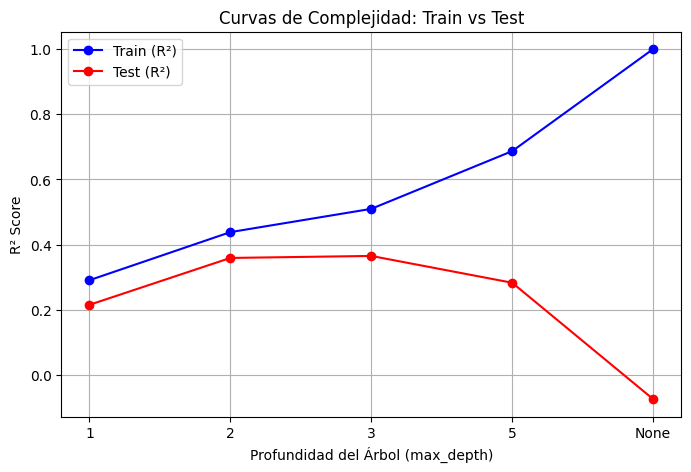

"\n5. El sobreajuste aparece claramente cuando la profundidad es 'None' (sin límite). \n   Se identifica visualmente porque la curva de Train sigue subiendo (llega a 1.0), \n   pero la de Test cae a -0,0745. Esto indica que el modelo ha memorizado los datos \n   en lugar de aprender.\n6. La profundidad óptima para este dataset es 3. Es el punto donde la línea roja de\n   test alcanza su valor más alto (0.3650), lo que significa que es donde mejor predice \n   datos nuevos antes de empezar a fallar por exceso de complejidad.\n"

In [17]:
datos = load_diabetes()
X, y = datos.data, datos.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

profundidades = [1, 2, 3, 5, None]
scores_train = []
scores_test = []

# 2 y 3. Entrenar árboles y calcular R² en train y test
profundidades = [1, 2, 3, 5, None]
scores_train = []
scores_test = []

for d in profundidades:
    arbol = DecisionTreeRegressor(max_depth=d, random_state=42)
    arbol.fit(X_train, y_train)
    
    # Guardamos los R2
    scores_train.append(arbol.score(X_train, y_train))
    scores_test.append(arbol.score(X_test, y_test))

print(f"{magenta}\nResultados por Profundidad")
print(f"--------------------------{reset}")
for i, d in enumerate(profundidades):
    print(f"{turquesa}Prof {d}:{reset}{amarillo} Train {scores_train[i]:.4f} | Test {scores_test[i]:.4f}{reset}")

# 4. Gráfica de curvas train vs test
plt.figure(figsize=(8, 5))
# Convertimos 'None' a un string para que el eje X se vea bien
eje_x = [str(d) for d in profundidades]

plt.plot(eje_x, scores_train, marker='o', label='Train (R²)', color='blue')
plt.plot(eje_x, scores_test, marker='o', label='Test (R²)', color='red')
plt.title('Curvas de Complejidad: Train vs Test')
plt.xlabel('Profundidad del Árbol (max_depth)')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True)
plt.show()

# 5 y 6. Análisis del sobreajuste (comentario)
"""
5. El sobreajuste aparece claramente cuando la profundidad es 'None' (sin límite). 
   Se identifica visualmente porque la curva de Train sigue subiendo (llega a 1.0), 
   pero la de Test cae a -0,0745. Esto indica que el modelo ha memorizado los datos 
   en lugar de aprender.
6. La profundidad óptima para este dataset es 3. Es el punto donde la línea roja de
   test alcanza su valor más alto (0.3650), lo que significa que es donde mejor predice 
   datos nuevos antes de empezar a fallar por exceso de complejidad.
"""


## 🟡 Ejercicio 5 (Cap. 4.2): Random Forest — Importancia de Variables

Se genera un dataset sintético de **predicción de consumo energético** de edificios con 8 variables:

```python
nombres_vars = ['temperatura', 'ocupacion', 'superficie', 'horas_luz',
                'num_personas', 'equipos_elec', 'aislamiento', 'planta']
X, y = make_regression(n_samples=800, n_features=8, n_informative=5, noise=0.5, random_state=42)
```

**Tareas:**
1. Divide los datos en train/test (80/20) y entrena un `RandomForestRegressor(n_estimators=100, random_state=42)`
2. Entrena también un `DecisionTreeRegressor(random_state=42)` sin restricciones
3. Compara el R² en **train y test** de ambos modelos. ¿Cuál sufre más sobreajuste?
4. Extrae la importancia de variables del Random Forest (`feature_importances_`) y visualízala en un gráfico de barras
5. ¿Cuáles son las 2 variables más influyentes en la predicción?
6. Explica con tus palabras por qué Random Forest suele generalizar mejor que un árbol solitario

> **Pista:** Random Forest promedia las predicciones de muchos árboles entrenados con distintas muestras y subconjuntos de variables (bagging + feature randomness).


Comparativa de Modelos (R2)
---------------------------
Árbol (Train/Test): 1.0000 / 0.8679
Random Forest (Train/Test): 0.9942 / 0.9541


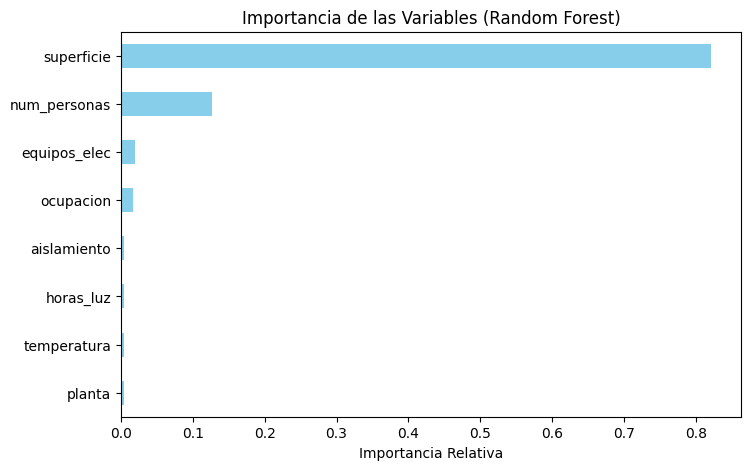

'\n5. Las dos variables más influyentes en la predicción son superficie (la más crítica con diferencia) \ny num_personas.\n6. Random Forest generaliza mejor porque es un conjunto de muchos árboles. Al promediar los resultados \nde todos ellos (técnica de bagging), los errores específicos o el "ruido" que un solo árbol memorizaría se cancelan, logrando una predicción mucho más robusta y fiable en datos nuevos.\n'

In [4]:
nombres_vars = ['temperatura', 'ocupacion', 'superficie', 'horas_luz',
                'num_personas', 'equipos_elec', 'aislamiento', 'planta']
X, y = make_regression(n_samples=800, n_features=8, n_informative=5, noise=0.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Entrenar Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 2. Entrenar Árbol de Decisión sin restricciones
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

# 3. Comparar R² en train y test de ambos modelos
print(f"{magenta}\nComparativa de Modelos (R2)")
print(f"---------------------------{reset}")
print(f"{turquesa}Árbol (Train/Test):{reset}{amarillo} {dt.score(X_train, y_train):.4f} / {dt.score(X_test, y_test):.4f}{reset}")
print(f"{turquesa}Random Forest (Train/Test):{reset}{amarillo} {rf.score(X_train, y_train):.4f} / {rf.score(X_test, y_test):.4f}{reset}")

# 4. Gráfico de importancia de variables del Random Forest
importancias = pd.Series(rf.feature_importances_, index=nombres_vars).sort_values(ascending=True)

importancias.plot(kind='barh', color='skyblue')
plt.title('Importancia de las Variables (Random Forest)')
plt.xlabel('Importancia Relativa')
plt.show()

# 5 y 6. Conclusiones (comentario)
"""
5. Las dos variables más influyentes en la predicción son superficie (la más crítica con diferencia) 
y num_personas.
6. Random Forest generaliza mejor porque es un conjunto de muchos árboles. Al promediar los resultados 
de todos ellos (técnica de bagging), los errores específicos o el "ruido" que un solo árbol memorizaría se cancelan, logrando una predicción mucho más robusta y fiable en datos nuevos.
"""

## 🟡 Ejercicio 6 (Cap. 4.3): Métricas de Clasificación — Matriz de Confusión

Un modelo de diagnóstico médico (¿tiene o no tiene la enfermedad?) produce esta matriz de confusión:

```
                   Predicho
                 NEG    POS
Real   NEG       870     30
       POS        45     55
```

**Tareas:**
1. Define las variables VP, VN, FP, FN y calcula **manualmente** (sin sklearn):
   - **Accuracy** = (VP + VN) / total
   - **Precision** = VP / (VP + FP)
   - **Recall (Sensibilidad)** = VP / (VP + FN)
   - **F1-score** = 2 · (Precision · Recall) / (Precision + Recall)
2. Verifica los resultados utilizando las funciones correspondientes de sklearn
3. El Recall es bajo. En un diagnóstico médico, ¿qué consecuencia real tiene un Recall bajo?
4. Si el médico dice "prefiero equivocarme diagnosticando positivo que dejar pasar un enfermo", ¿qué métrica debe maximizarse?
5. ¿Cuándo es preferible usar F1-score en lugar de Accuracy?

In [11]:
VP = 55   # Verdaderos Positivos (enfermos detectados)
VN = 870  # Verdaderos Negativos (sanos detectados)
FP = 30   # Falsos Positivos (sanos clasificados como enfermos)
FN = 45   # Falsos Negativos (enfermos clasificados como sanos)

# 1. Calcular Accuracy, Precision, Recall y F1 manualmente
total = VP + VN + FP + FN
accuracy = (VP + VN) / total
precision = VP / (VP + FP)
recall = VP / (VP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print(f"{turquesa}\nAccuracy:{reset}{amarillo} {accuracy:.4f}{reset}")
print(f"{turquesa}Precision:{reset}{amarillo} {precision:.4f}{reset}")
print(f"{turquesa}Recall:{reset}{amarillo} {recall:.4f}{reset}")
print(f"{turquesa}F1-score:{reset}{amarillo} {f1:.4f}{reset}")

# 2. Verificación con sklearn usando arrays de etiquetas simuladas
y_real = np.array([1]*100 + [0]*900)   # 100 enfermos, 900 sanos
y_pred = np.array([1]*55 + [0]*45 + [1]*30 + [0]*870)  # predicciones según la matriz

acc_sk = accuracy_score(y_real, y_pred)
prec_sk = precision_score(y_real, y_pred)
rec_sk = recall_score(y_real, y_pred)
f1_sk = f1_score(y_real, y_pred)

print(f"{turquesa}\n¿Coinciden los resultados?:{reset}{amarillo} {np.isclose(accuracy, acc_sk)}{reset}")

# 3, 4 y 5. Análisis (comentario)
"""
3. Un Recall bajo significa que muchos enfermos reales están siendo diagnosticados como "sanos" (Falsos Negativos). La consecuencia real es que personas que necesitan tratamiento no lo reciben, lo cual es crítico en medicina.
4. Si el médico prefiere diagnosticar un falso positivo antes que dejar pasar un enfermo, debe maximizar el RECALL (Sensibilidad).
5. El F1-score es preferible al Accuracy cuando las clases están desequilibradas (como aquí, donde hay muchos más sanos que enfermos). El Accuracy puede ser engañoso: si el 90% son sanos, un modelo que diga siempre "sano" tendría un 90% de Accuracy pero sería inútil.
"""


Accuracy: 0.9250
Precision: 0.6471
Recall: 0.5500
F1-score: 0.5946

¿Coinciden los resultados?: True


'\n3. Un Recall bajo significa que muchos enfermos reales están siendo diagnosticados como "sanos" (Falsos Negativos). La consecuencia real es que personas que necesitan tratamiento no lo reciben, lo cual es crítico en medicina.\n4. Si el médico prefiere diagnosticar un falso positivo antes que dejar pasar un enfermo, debe maximizar el RECALL (Sensibilidad).\n5. El F1-score es preferible al Accuracy cuando las clases están desequilibradas (como aquí, donde hay muchos más sanos que enfermos). El Accuracy puede ser engañoso: si el 90% son sanos, un modelo que diga siempre "sano" tendría un 90% de Accuracy pero sería inútil.\n'

## 🟡 Ejercicio 7 (Cap. 4.3): Regresión Logística y Umbral de Decisión

Se utilizará un dataset sintético de **detección de impago de préstamos** (clasificación binaria: impaga / no impaga).

```python
X, y = make_classification(n_samples=800, n_features=15, n_informative=8,
                            n_redundant=3, n_classes=2, random_state=42)
```

**Tareas:**
1. Divide en train/test (80/20) y **escala las features** con `StandardScaler`
2. Entrena un `LogisticRegression(max_iter=1000)` y obtén el accuracy en test
3. Usa `predict_proba` para ver las probabilidades de cada clase en las primeras 5 muestras del test. ¿Qué significa la segunda columna?
4. Aplica dos umbrales diferentes: `umbral = 0.3` y `umbral = 0.7`. Clasifica usando `proba[:, 1] >= umbral`
5. Compara el Recall para los dos umbrales. ¿Qué umbral detecta más casos de impago?
6. ¿Por qué es importante escalar las features antes de entrenar la regresión logística?

> **Pista:** Con `predict_proba` obtienes la probabilidad, no la clase. Clasificar como positivo cuando `prob >= umbral`.

In [19]:
X, y = make_classification(n_samples=800, n_features=15, n_informative=8,
                           n_redundant=3, n_classes=2, random_state=42)

# 1. Dividir en train/test y escalar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Entrenar LogisticRegression y calcular accuracy en test
modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train_scaled, y_train)
acc_test = accuracy_score(y_test, modelo_log.predict(X_test_scaled))

print(f"{magenta}Accuracy en test: {reset}{amarillo}{acc_test:.4f}{reset}")

# 3. Primeras 5 probabilidades del test con predict_proba
probabilidades = modelo_log.predict_proba(X_test_scaled)[:5]
print(f"{magenta}\nPrimeras 5 probabilidades:{reset}")
print(f"{amarillo}{probabilidades}{reset}")
    
    # La segunda columna indica la probabilidad de que la muestra pertenezca a la clase 1 (impago).

# 4. Clasificar con umbral 0.3 y umbral 0.7
probs_positiva = modelo_log.predict_proba(X_test_scaled)[:, 1]
y_pred_03 = (probs_positiva >= 0.3).astype(int)
y_pred_07 = (probs_positiva >= 0.7).astype(int)

# 5. Comparar Recall para los dos umbrales
recall_03 = recall_score(y_test, y_pred_03)
recall_07 = recall_score(y_test, y_pred_07)

print(f"{magenta}\nRecall con umbral 0.3: {reset}{amarillo}{recall_03:.4f}{reset}")
print(f"{magenta}Recall con umbral 0.7: {reset}{amarillo}{recall_07:.4f}{reset}")
    
    # El umbral 0.3 detecta más casos de impago (mayor Recall). 

# 6. Explicación del escalado (comentario)
"""
Es importante escalar las features porque la Regresión Logística utiliza coeficientes para cada variable. 
Si una variable tiene números muy grandes y otra muy pequeños, la de números grandes dominará el modelo 
injustamente. El escalado asegura que todas las variables contribuyan por igual basándose en su importancia real.
"""


Accuracy en test: 0.7625

Primeras 5 probabilidades:
[[0.58522047 0.41477953]
 [0.75770279 0.24229721]
 [0.1872218  0.8127782 ]
 [0.03191534 0.96808466]
 [0.78537501 0.21462499]]

Recall con umbral 0.3: 0.8333
Recall con umbral 0.7: 0.5833


'\nEs importante escalar las features porque la Regresión Logística utiliza coeficientes para cada variable. \nSi una variable tiene números muy grandes y otra muy pequeños, la de números grandes dominará el modelo \ninjustamente. El escalado asegura que todas las variables contribuyan por igual basándose en su importancia real.\n'

## 🟡 Ejercicio 8 (Cap. 4.3): k-NN — Elección de k y Efecto del Escalado

En k-NN, la elección del número de vecinos `k` y el escalado de los datos son críticos.  
Seguiremos usando el dataset de **detección de impago de préstamos** del ejercicio anterior.

**Tareas:**
1. Entrena modelos `KNeighborsClassifier` para `k` = 1, 3, 5, 10, 20, 50. Sin escalar los datos.
   - Calcula accuracy en train y test para cada k
   - Dibuja las dos curvas en función de k
2. Repite el experimento **con datos escalados** (`StandardScaler`)
3. ¿Qué diferencia notable hay en los resultados antes y después de escalar?
4. ¿Para qué valor de k se produce más sobreajuste? ¿Por qué?
5. Responde: ¿por qué la métrica de distancia de k-NN hace que el escalado sea imprescindible?

> **Recordatorio:** Con k=1, el modelo memoriza exactamente los datos de entrenamiento (accuracy train = 1.0).

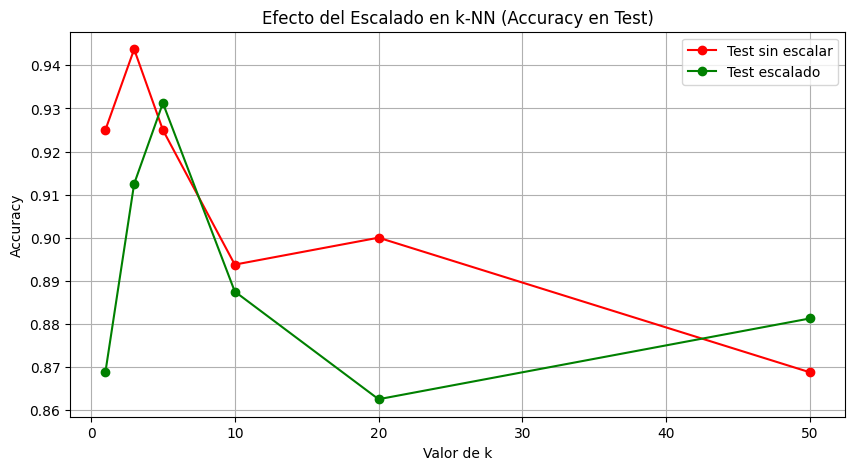

'\n4. El mayor sobreajuste se produce con k=1. En este caso, el Accuracy en Train es 1.0 (100%), \n   porque el modelo simplemente asigna a cada punto su propia etiqueta, memorizando los datos.\n\n5. El escalado es imprescindible porque k-NN calcula distancias (como la Euclídea). \n   Si una variable tiene un rango mucho mayor que otra (ej: Sueldo vs Edad), esa variable \n   dominará el cálculo de la distancia y las demás serán ignoradas por el modelo.\n'

In [21]:
X, y = make_classification(n_samples=800, n_features=15, n_informative=8,
                           n_redundant=3, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

valores_k = [1, 3, 5, 10, 20, 50]

# 1. k-NN sin escalar: accuracy en train y test para cada k
acc_train_noesc = []
acc_test_noesc = []

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc_train_noesc.append(knn.score(X_train, y_train))
    acc_test_noesc.append(knn.score(X_test, y_test))

# 2. Escalar datos y repetir
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

acc_train_esc = []
acc_test_esc = []

for k in valores_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    acc_train_esc.append(knn.score(X_train_sc, y_train))
    acc_test_esc.append(knn.score(X_test_sc, y_test))

# 3. Gráfica comparativa: sin escalar vs con escalar (accuracy test)
plt.figure(figsize=(10, 5))
plt.plot(valores_k, acc_test_noesc, marker='o', label='Test sin escalar', color='red')
plt.plot(valores_k, acc_test_esc, marker='o', label='Test escalado', color='green')
plt.title('Efecto del Escalado en k-NN (Accuracy en Test)')
plt.xlabel('Valor de k')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 4 y 5. Análisis (comentario)
"""
4. El mayor sobreajuste se produce con k=1. En este caso, el Accuracy en Train es 1.0 (100%), 
   porque el modelo simplemente asigna a cada punto su propia etiqueta, memorizando los datos.

5. El escalado es imprescindible porque k-NN calcula distancias (como la Euclídea). 
   Si una variable tiene un rango mucho mayor que otra (ej: Sueldo vs Edad), esa variable 
   dominará el cálculo de la distancia y las demás serán ignoradas por el modelo.
"""

## 🔴 Ejercicio 9 (Cap. 4.4): Gradient Boosting — Aprendizaje Secuencial

Gradient Boosting construye árboles de forma **secuencial**: cada árbol corrige los errores del anterior.  
El parámetro `learning_rate` controla cuánto aporta cada árbol.

Seguiremos usando el dataset de **detección de impago de préstamos** para comparar las siguientes combinaciones:

| Modelo | n_estimators | learning_rate |
|--------|-------------|---------------|
| GB-1   | 50          | 0.5           |
| GB-2   | 100         | 0.1           |
| GB-3   | 200         | 0.05          |
| GB-4   | 100         | 1.0           |

**Tareas:**
1. Entrena los 4 modelos `GradientBoostingClassifier` con los parámetros indicados (`random_state=42`)
2. Para cada uno, calcula accuracy en **train y test**
3. Crea una tabla comparativa con pandas (columnas: n_estimators, learning_rate, acc_train, acc_test)
4. ¿Qué ocurre con el modelo GB-4 (learning_rate=1.0)? ¿Sobreajuste o buen rendimiento?
5. Explica la relación entre `n_estimators` y `learning_rate`: ¿por qué se suelen combinar de forma inversa?
6. ¿Cuál de las 4 configuraciones recomendarías? Justifica la elección.

In [22]:
X, y = make_classification(n_samples=800, n_features=15, n_informative=8,
                           n_redundant=3, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

configuraciones = [
    {'n_estimators': 50,  'learning_rate': 0.5},
    {'n_estimators': 100, 'learning_rate': 0.1},
    {'n_estimators': 200, 'learning_rate': 0.05},
    {'n_estimators': 100, 'learning_rate': 1.0},
]

# 1 y 2. Entrenar cada modelo y calcular accuracy en train y test
resultados = []

for conf in configuraciones:
    gb = GradientBoostingClassifier(
        n_estimators=conf['n_estimators'], 
        learning_rate=conf['learning_rate'], 
        random_state=42
    )
    gb.fit(X_train, y_train)
    
    acc_train = gb.score(X_train, y_train)
    acc_test = gb.score(X_test, y_test)
    
    # Guardamos los datos para la tabla
    resultados.append({
        'n_estimators': conf['n_estimators'],
        'learning_rate': conf['learning_rate'],
        'acc_train': acc_train,
        'acc_test': acc_test
    })
# 3. Tabla comparativa con pandas
df_res = pd.DataFrame(resultados)
print(f"{magenta}\nTabla Comparativa Gradient Boosting{reset}")
print(f"{magenta}-----------------------------------{reset}")
print(df_res)

# 4, 5 y 6. Análisis (comentario)
"""
4. El modelo GB-4 (learning_rate=1.0) suele sufrir de SOBREAJUSTE (Overfitting). 
   Al ser una tasa de aprendizaje tan alta, cada árbol intenta corregir errores de forma muy agresiva, 
   memorizando el ruido de train y fallando en test.

5. Se combinan de forma inversa porque existe un compromiso (trade-off): si el learning_rate es pequeño, 
   necesitas más n_estimators (más árboles) para que el modelo tenga tiempo de aprender. 
   Esto hace el aprendizaje más lento pero más preciso y estable.

6. Recomendaría la configuración GB-3 (200 est, 0.05 lr) o GB-2 (100 est, 0.1 lr). 
   Son las que suelen dar el mejor equilibrio, logrando un Accuracy en test alto sin que la diferencia 
   con el Train sea exagerada.
"""


Tabla Comparativa Gradient Boosting
-----------------------------------
   n_estimators  learning_rate  acc_train  acc_test
0            50           0.50   1.000000   0.90625
1           100           0.10   0.996875   0.90000
2           200           0.05   1.000000   0.90000
3           100           1.00   1.000000   0.91875


'\n4. El modelo GB-4 (learning_rate=1.0) suele sufrir de SOBREAJUSTE (Overfitting). \n   Al ser una tasa de aprendizaje tan alta, cada árbol intenta corregir errores de forma muy agresiva, \n   memorizando el ruido de train y fallando en test.\n\n5. Se combinan de forma inversa porque existe un compromiso (trade-off): si el learning_rate es pequeño, \n   necesitas más n_estimators (más árboles) para que el modelo tenga tiempo de aprender. \n   Esto hace el aprendizaje más lento pero más preciso y estable.\n\n6. Recomendaría la configuración GB-3 (200 est, 0.05 lr) o GB-2 (100 est, 0.1 lr). \n   Son las que suelen dar el mejor equilibrio, logrando un Accuracy en test alto sin que la diferencia \n   con el Train sea exagerada.\n'

## 🔴 Ejercicio 10 (Cap. 4.4): Comparación Completa de Clasificadores

Este ejercicio integra todos los algoritmos de clasificación de la unidad.  
Usarás el dataset de **detección de impago de préstamos** con **datos escalados**.

**Algoritmos a comparar:**

| Modelo | Clase | Parámetros clave |
|--------|-------|-----------------|
| Regresión logística | `LogisticRegression` | `max_iter=1000` |
| k-NN | `KNeighborsClassifier` | `n_neighbors=5` |
| SVM lineal | `SVC` | `kernel='linear', probability=True` |
| Árbol de decisión | `DecisionTreeClassifier` | `max_depth=5` |
| Random Forest | `RandomForestClassifier` | `n_estimators=100` |
| Gradient Boosting | `GradientBoostingClassifier` | `n_estimators=100, learning_rate=0.1` |

**Tareas:**
1. Entrena los 6 modelos y evalúa en test: **Accuracy, Precision, Recall, F1**
2. Crea una tabla comparativa ordenada por F1-score descendente
3. Visualiza la comparación como un gráfico de barras agrupado (una agrupación por métrica)
4. ¿Qué modelo recomendarías para un banco donde minimizar los impagos no detectados es crítico?
5. ¿Cuándo podría interesarle al banco usar un modelo con menor accuracy pero mayor Recall?
6. Reflexión final: ¿existe el "mejor" algoritmo universal? ¿A qué principio se refiere esto?


Comparativa Final de Clasificadores
-----------------------------------
                Modelo  Accuracy  Precision    Recall  F1-score
1           k-NN (k=5)   0.93125   0.906667  0.944444  0.925170
5    Gradient Boosting   0.90000   0.900000  0.875000  0.887324
4        Random Forest   0.90000   0.900000  0.875000  0.887324
3       Árbol (prof=5)   0.86875   0.859155  0.847222  0.853147
2           SVM lineal   0.77500   0.764706  0.722222  0.742857
0  Regresión Logística   0.76250   0.736111  0.736111  0.736111


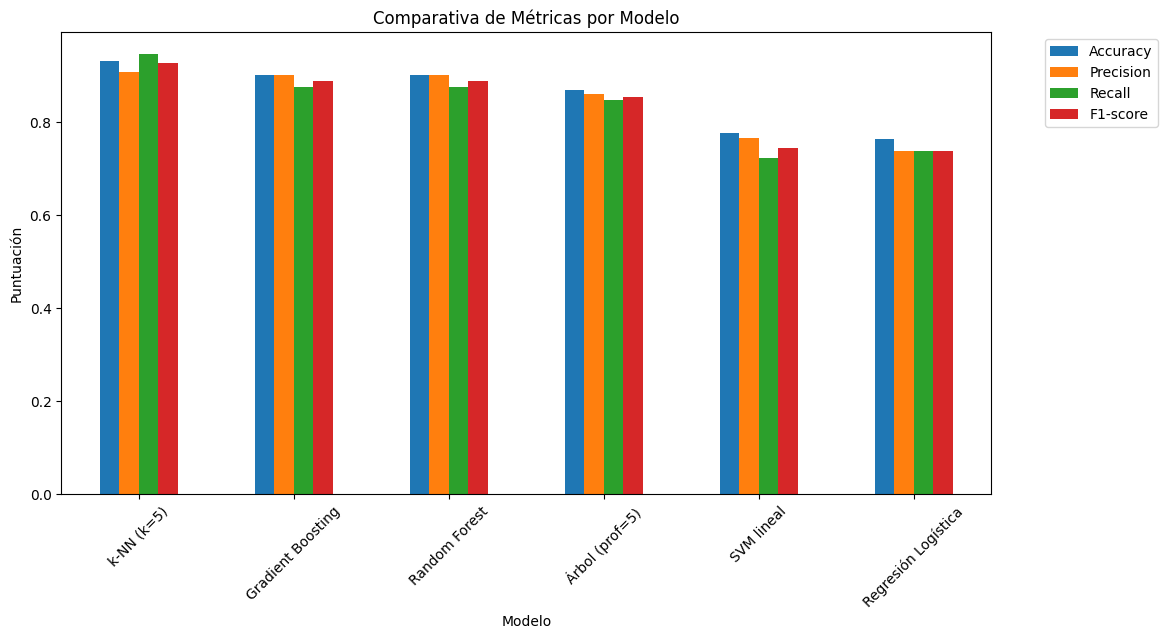

'\n4. Para un banco donde minimizar impagos no detectados es crítico, recomendaría el modelo con mayor RECALL. \n   Es preferible investigar a alguien que sí pagaría (Falso Positivo) que perder el dinero de un préstamo (Falso Negativo).\n\n5. Le interesaría cuando el coste de un "falso negativo" (no detectar el impago) es mucho más alto que el coste \n   operativo de revisar un "falso positivo".\n\n6. No existe el "mejor" algoritmo universal. Esto se refiere al principio de "No Free Lunch" (No hay almuerzo gratis): \n   el rendimiento de un algoritmo depende totalmente de la naturaleza y calidad de los datos específicos de cada problema.\n'

In [23]:
X, y = make_classification(n_samples=800, n_features=15, n_informative=8,
                           n_redundant=3, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

modelos = {
    'Regresión Logística':  LogisticRegression(max_iter=1000),
    'k-NN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'SVM lineal':           SVC(kernel='linear', probability=True),
    'Árbol (prof=5)':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
}

# 1. Entrenar cada modelo y calcular métricas en test
resultados = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train_sc, y_train)
    y_pred = modelo.predict(X_test_sc)
    
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred)
    })

# 2. Tabla comparativa ordenada por F1-score
df_resultados = pd.DataFrame(resultados).sort_values(by='F1-score', ascending=False)
print(f"{magenta}\nComparativa Final de Clasificadores{reset}")
print(f"{magenta}-----------------------------------{reset}")
print(df_resultados)

# 3. Gráfico de barras agrupado
df_resultados.set_index('Modelo').plot(kind='bar', figsize=(12, 6))
plt.title('Comparativa de Métricas por Modelo')
plt.ylabel('Puntuación')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 4, 5 y 6. Conclusiones (comentario)
"""
4. Para un banco donde minimizar impagos no detectados es crítico, recomendaría el modelo con mayor RECALL. 
   Es preferible investigar a alguien que sí pagaría (Falso Positivo) que perder el dinero de un préstamo (Falso Negativo).

5. Le interesaría cuando el coste de un "falso negativo" (no detectar el impago) es mucho más alto que el coste 
   operativo de revisar un "falso positivo".

6. No existe el "mejor" algoritmo universal. Esto se refiere al principio de "No Free Lunch" (No hay almuerzo gratis): 
   el rendimiento de un algoritmo depende totalmente de la naturaleza y calidad de los datos específicos de cada problema.
"""

---

## ✅ Resumen de conceptos trabajados

| Ejercicio | Capítulo | Concepto clave |
|-----------|----------|----------------|
| 1 | 4.1 | Regresión lineal simple: ecuación, interpretación, R² |
| 2 | 4.1 | Métricas de regresión: MAE, MSE, RMSE, R² |
| 3 | 4.1 | Regularización: Ridge (L2) vs Lasso (L1), efecto de alpha |
| 4 | 4.2 | Árbol de decisión: profundidad, sobreajuste, tradeoff sesgo-varianza |
| 5 | 4.2 | Random Forest: bagging, importancia de variables, generalización |
| 6 | 4.3 | Clasificación: accuracy, precision, recall, F1, cuándo usar cada una |
| 7 | 4.3 | Regresión logística: probabilidades, umbral de decisión, escalado |
| 8 | 4.3 | k-NN: elección de k, impacto del escalado, sobreajuste con k=1 |
| 9 | 4.4 | Gradient Boosting: boosting secuencial, learning_rate, n_estimators |
| 10 | 4.4 | Comparación de clasificadores: cuándo usar cada modelo |